In [2]:
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('~/repositories/go_figure/ClassicScience.mplstyle')

# plt.rcParams.update({
#     "font.family": "serif",
#     "text.usetex": True})

plt.rcParams.update({
    # "font.family"       : "serif",
    # "text.usetex"       : True,

    # No minor ticks => half as many tick marks immediately
    "xtick.minor.visible": False,
    "ytick.minor.visible": False,

    # … optional cosmetics
    "xtick.major.size"  : 4,     # length  of the remaining ticks
    "ytick.major.size"  : 4,
    "xtick.major.width" : 0.9,   # thickness of the ticks
    "ytick.major.width" : 0.9,
})

%load_ext autoreload
%autoreload 2

In [3]:
def set_plot_fontsizes(base=8, ticks=7, legend=7, title=None):
    import matplotlib.pyplot as plt
    if title is None:
        title = base
    plt.rcParams.update({
        "font.size": base,
        "axes.titlesize": title,
        "axes.labelsize": base,
        "legend.fontsize": legend,
        "xtick.labelsize": ticks,
        "ytick.labelsize": ticks,
        "figure.titlesize": title,
    })

In [4]:
import sys,os
# sys.path.insert(0, os.path.abspath("/Users/lucas/repositories/degeneracy_distillery/results/"))

os.chdir("/Users/lucas/repositories/degeneracy_distillery/results/")

In [5]:
import pickle

from degeneracy_distillery.postprocessing_utils import (
    lossfn_jac_jax,
    get_component,
    get_pruned_expressions,
    get_pruned_expressions_final,
    check_flattening,
    make_check_flattening_fn,
    get_Q_jax, construct_M,
    postprocess_eqs,
    # analyze_equations

)

from degeneracy_distillery.preprocessing_utils import get_eigenvalues as get_evalues

def save_obj(obj, name):
    with open(f'{name}.pkl', 'wb') as f:
        pickle.dump(obj, f)

def load_obj(name):
    with open(f'{name}', 'rb') as f:
        return pickle.load(f)

analysis = load_obj("ex_mu_sigma/sr_analysis.pkl")
split_data = np.load("ex_mu_sigma/split_data.npz")


# Access test data for further analysis
X_test = split_data['X_test']
y_test = split_data['y_test']
Fs_test = split_data['Fs_test']
y_std_test = split_data['y_std_test']
dy_sr_test = split_data['dy_sr_test']


norm_factor = np.load("ex_mu_sigma/mu_sigma.npz")["norm_factor"]

from degeneracy_distillery.sr_utils import fit_and_analyze_sr, analyze_equations


n_params=2

mdl_coords, frob_coords, _ = analyze_equations(
    X_test, y_test, y_std_test, dy_sr_test, Fs_test,
    parent_dir="ex_mu_sigma/",
    n_params=2,
    equation_set='pareto',
    max_complexity_thresh=25,
)


Analysing component 1 of 2 (index 0)
Loading equations from: pareto.csv
17 equations below complexity threshold 25


Component 1: 100%|██████████████████████████████████████████████████████████████████████████████████████████| 17/17 [00:24<00:00,  1.44s/it]



Best MDL equation (complexity=17):
  (7.271622 + ((((exp((0.952197 * X2)) + (((-1.258422) * X1) * (2.666616 * X1))) * (0.016555 * X1)) + (2.784939 * X1)) * (exp((0.135525 * X2)) + ((-0.366447) * X2))))
  LaTeX: $b_{0} + \left(X_{2} b_{7} + e^{X_{2} b_{6}}\right) \left(X_{1} b_{4} \left(X_{1}^{2} b_{2} b_{3} + e^{X_{2} b_{1}}\right) + X_{1} b_{5}\right)$

Best Frob loss equation (complexity=18):
  (7.272122 + (0.999395 * ((0.293347 * X1) + ((((((-0.057999) * X1) * (0.734129 * X1)) * (1.393795 * X1)) + (2.599529 * X1)) * (exp(((-0.282213) * X2)) + ((-0.022043) * X2))))))
  LaTeX: $b_{0} + b_{1} \left(X_{1} b_{2} + \left(X_{2} b_{8} + e^{X_{2} b_{7}}\right) \left(X_{1}^{3} b_{3} b_{4} b_{5} + X_{1} b_{6}\right)\right)$

Analysing component 2 of 2 (index 1)
Loading equations from: pareto.csv
16 equations below complexity threshold 25


Component 2: 100%|██████████████████████████████████████████████████████████████████████████████████████████| 16/16 [00:05<00:00,  3.07it/s]



Best MDL equation (complexity=19):
  ((-0.726524) + ((-11.446799) * ((-0.251491) * ((((((1.860714 * X1) * (0.073813 * X1)) + (0.425107 * X2)) + ((-0.015005) * X1)) ^ exp(((-0.272544) * X2))) * exp((0.124175 * X2))))))
  LaTeX: $b_{0} + b_{1} b_{2} \left(X_{1}^{2} b_{3} b_{4} + X_{1} b_{6} + X_{2} b_{5}\right)^{e^{X_{2} b_{7}}} e^{X_{2} b_{8}}$

Best Frob loss equation (complexity=18):
  ((-0.001873) + (1.000670 * (((0.829219 * X2) + (-0.879226)) + (((((4.407253 * X1) * (0.093729 * X1)) + ((-0.043992) * X1)) + (1.162288 * X2)) ^ exp(((-0.126380) * X2))))))
  LaTeX: $b_{0} + b_{1} \left(X_{2} b_{2} + b_{3} + \left(X_{1}^{2} b_{4} b_{5} + X_{1} b_{6} + X_{2} b_{7}\right)^{e^{X_{2} b_{8}}}\right)$


In [40]:
norm_factor

array(6.4315834)

In [6]:
# One-liner with all options
pruned_exprs, consts, A_opt = postprocess_eqs(
    coordinates=mdl_coords,
    X=X_test, Fs=Fs_test, n_params=2,
    optimize_rotation="none",
    rotation_params={
        # "lambda_sparse": 0.5,
        # "lambda_flat": 10.0,
        "maxiter": 500
    },
    threshold=0.05
)
pruned_exprs

Parsing 2 symbolic expressions...
Found 17 total parameters (9 linear)

Starting pruning with threshold=0.05...
initial flattening score: 2.361765
computing importance scores for all coefficients...
Importance scores - min: 0.000000e+00, max: 2.084814e+00, median: 0.000000e+00


pruning coefficients:  67%|████████████████████████████████████▋                  | 6/9 [00:01<00:00,  4.02it/s, removed=4, delta=-0.061766]

zeroing coeff (0,4) caused error - keeping it
coeff (0,5) - importance 0.000000e+00: delta 664.261353 exceeds threshold, keeping


pruning coefficients: 100%|███████████████████████████████████████████████████████| 9/9 [00:02<00:00,  3.96it/s, removed=5, delta=-0.061766]


zeroing coeff (1,1) caused error - keeping it
zeroing coeff (1,2) caused error - keeping it

pruning summary: removed 5/9 coefficients

Postprocessing complete!
Input expressions: 2
Output expressions: 2


['X1*(-1.021*X2 + 2.785*exp(0.136*X2))',
 '2.879*(0.137*X1**2 - 0.015*X1 + 0.425*X2)**exp(-0.273*X2)*exp(0.124*X2)']

In [33]:
# Import preprocessing (rotations, data loading)
from degeneracy_distillery.preprocessing_utils import (
    load_and_process_data,
    process_ensemble_rotation,
    flatten_with_numerical_jacobian,
    batch_flatten_fisher,
    rotate_coords,
    load_and_process_data,
    weighted_std
)

# Import postprocessing (SR optimization)
from degeneracy_distillery.postprocessing_utils import (
    lossfn_jac_jax,
    get_component,
    get_pruned_expressions,
    get_pruned_expressions_final,
    check_flattening,
    make_check_flattening_fn,
)

In [34]:
# insert Deaglan's and Ben's coordinates

ad_hoc_coords = ['X1 * (1. / sqrt(X2)) * sqrt(50.)', 'log(X2) * sqrt(50.)']

# ad_hoc_coords = ['X1 * (1. / sqrt(X2))', 'log(X2)']


# now geodesic normal coordinates

theta_star = np.array([0.0, 1.0])

def get_geo_coordinates(X, theta_star=theta_star):
    x1, x2 = X

    mu = x1
    sg = x2

    sg_star = (theta_star[1])
    mu_star = theta_star[0]
    
    beta = jnp.arcsinh( 
        ((1./(2. * sg_star * sg)) ) \
                * ((0.5 * (mu - mu_star)**2 + (sg - sg_star)**2)
                       * (0.5 * (mu - mu_star)**2 + (sg + sg_star)**2))**0.5
    )

    eta = jnp.where((mu == mu_star), jnp.sqrt(2.0) * beta * jnp.sign(0.5 * (mu - mu_star)**2 + sg**2 - sg_star**2),
                   0.5 * (mu - mu_star)**2 + sg**2 - sg_star**2 \
                      * jnp.sign(0.5 * (mu - mu_star)**2 + sg**2 - sg_star**2)
    ) # \eta

    # y1 = 0.5 * (mu - mu_star)**2 + sg**2 - sg_star**2 \
    #                  * jnp.sign(0.5 * (mu - mu_star)**2 + sg**2 - sg_star**2)
    
    xi = jnp.where((mu == mu_star), 0.0, 
                   sg_star * (mu - mu_star) * jnp.sqrt(2.0) * jnp.sign(mu - mu_star)
    ) # \xi

    # y2 = sg_star * (mu - mu_star) * jnp.sqrt(2.0) * jnp.sign(mu - mu_star)

    return jnp.array([xi, eta]) #/ jnp.sqrt(50.)



def get_beta(X, theta_star=theta_star, return_beta=False):

    x1,x2 = X
    mu = x1
    sg = x2

    sg_star = (theta_star[1])
    mu_star = theta_star[0]
    
    beta = jnp.arcsinh( 
        ((1./(2. * sg_star * sg)) ) \
                * ((0.5 * (mu - mu_star)**2 + (sg - sg_star)**2)
                       * (0.5 * (mu - mu_star)**2 + (sg + sg_star)**2))**0.5

    )
    if return_beta:
        return ((jnp.sinh(beta)**2.0) / beta**2.0) - 1.0, beta
    else:
        return ((jnp.sinh(beta)**2.0) / beta**2.0) - 1.0  #(1./3.) * beta**2


geo_coordinates = ['0.5 * (X1 - 0.)^2 + X2 - 1.0', '1.0 * (X1 - 0.) * sqrt(2.)']

# FUNCTIONS FOR CHECKING THE FLATNESS OF NEURAL AND NUMERICAL FNs
frobenius_norm_loss = lambda q: norm((q - jnp.eye(n_params))) #+ norm((jnp.linalg.inv(q) - jnp.eye(n_params)))




def check_numerical_fn_flattening(Xs, Fs, get_frob=True, myfunc=get_geo_coordinates):

    flatfn = lambda x,f: flatten_with_fn(x,f, myfunc=myfunc)
    flats = jax.vmap(flatfn)(Xs, Fs)

    if get_frob:
        return flats, jax.vmap(frobenius_norm_loss)(flats)
    else:
        return flats


def check_neural_flattening(Js, Fs, get_frob=True):
    flats = jax.vmap(flatten_with_numerical_jacobian)(Js, Fs)
    if get_frob:
        return flats, jax.vmap(frobenius_norm_loss)(flats).mean()
    else:
        return flats


def flatten_with_fn(X, F, myfunc=get_geo_coordinates):    
    J_eta = jax.jacobian(myfunc)(X)
    Jeta_inv = jnp.linalg.pinv(J_eta)

    Q = Jeta_inv.T @ F @ Jeta_inv # REVERSED THIS FOR ANALYTIC CONVENTION

    return Q


In [35]:
import jax.numpy as jnp
import jax


sigma_star = 1.0
mu_star = 0.0

u_star = mu_star / sigma_star
v_star = jnp.sqrt(2)

def x_to_sinhbeta(x):
    sinh_beta = jnp.sqrt(
            (0.5 * (x[0] - mu_star)**2 + (x[1] - sigma_star)**2) *
            (0.5 * (x[0] - mu_star)**2 + (x[1] + sigma_star)**2)
        ) / x[1] / sigma_star / 2
    return sinh_beta


def xp_to_beta(xp):
    xi, eta = xp
    beta = jnp.sqrt(xi**2 + eta**2) / v_star
    return beta


def get_beta(X, return_beta=False):    
    xp = x_to_xprime(X)
    beta = xp_to_beta(xp)

    if return_beta:
        return ((jnp.sinh(beta)**2.0) / beta**2.0) - 1.0, beta
    else:
        return ((jnp.sinh(beta)**2.0) / beta**2.0) - 1.0  #(1./3.) * beta**2
    

def x_to_xprime(x):
    sinh_beta = x_to_sinhbeta(x)
    beta = jnp.arcsinh(sinh_beta)
    
    xi = jnp.where(jnp.abs(beta) > 1e-4,
                   beta * (x[0] - mu_star) / x[1] / sinh_beta,
                    0,
    )
    eta = jnp.where(jnp.abs(beta) > 1e-4,
                xi * (0.5 * (x[0] - mu_star)**2 + x[1] ** 2 - sigma_star**2) / 
                (sigma_star * (x[0] - mu_star) * jnp.sqrt(2)),
                0,
    )
    xprime = jnp.array([xi, eta])
    return xprime


def xprime_to_x(xp):

    beta = xp_to_beta(xp)
    xi, eta = xp
    u = jnp.where(beta == 0,
                   u_star,
                    (u_star + 
                        v_star * xi * jnp.sinh(beta) / 
                        (beta * v_star * jnp.cosh(beta) - eta * jnp.sinh(beta))
                    )
    )

    v = jnp.where(beta == 0,
                    v_star,
                    v_star * (
                        beta * v_star / 
                        (beta * v_star * jnp.cosh(beta) - eta * jnp.sinh(beta))
                    )
    )

    x = jnp.array([u * sigma_star, v * sigma_star / jnp.sqrt(2)])

    return x

def metric_fn(x):
    g = jnp.zeros((2, 2))
    g = g.at[0, 0].set(1 / x[1] ** 2)
    g = g.at[1, 1].set(2 / x[1] ** 2)
    return g


def transformed_metric(xp):
    x = xprime_to_x(xp)
    J = jax.jacfwd(x_to_xprime)(x)
    Jinv = jnp.linalg.pinv(J)
    g = metric_fn(x)
    return Jinv.T @ g @ Jinv


def predicted_metric(xp):
    beta = xp_to_beta(xp)
    if beta == 0:
        return jnp.eye(2)
    xi, eta = xp
    g = jnp.zeros((2, 2))
    g = g.at[0, 0].set(eta**2 * jnp.sinh(beta)**2 + xi**2 * beta**2)
    g = g.at[0, 1].set(xi * eta * (beta ** 2 - jnp.sinh(beta)**2))
    g = g.at[1, 0].set(g[0, 1])
    g = g.at[1, 1].set(eta**2 * beta **2 + xi**2 * jnp.sinh(beta)**2)
    g = g / 2 / beta ** 4
    
    return g

In [44]:
# create some true fishers everywhere

def true_fisher(X):
    n_d = 50
    mu = X[0]
    sig = (X[1])
    return n_d * jnp.array([[1./sig**2, 0.0],[0.0, 2. / sig**2]])

true_fs = jax.vmap(true_fisher)(X_test) / norm_factor # NORMALISE TO THE FISHNETS ONES

gb = lambda x: get_beta(x, return_beta=True)
_, betas = jax.vmap(gb)(X_test)
frb = jax.vmap(frobenius_norm_loss)




check_flats = lambda c: check_flattening(c, X=X_test, Fs=Fs_test)
from degeneracy_distillery.sr_utils import norm


In [45]:
((true_fs) - Fs_test) / true_fs

Array([[[-0.41543686,        -inf],
        [       -inf,  0.5209002 ]],

       [[-0.11742204,        -inf],
        [       -inf,  0.6525725 ]],

       [[-0.37044203,        -inf],
        [       -inf,  0.23241246]],

       ...,

       [[ 0.28165594,         inf],
        [        inf,  0.45180395]],

       [[-0.07180747,        -inf],
        [       -inf,  0.6456242 ]],

       [[-0.09673987,         inf],
        [        inf,  0.29134387]]], dtype=float32)


checking against true fishers
---
neural network flattening score: 1.3310512
MDL SR flattening score: 1.3481759
Frob SR flattening score: 1.278283
ad-hoc flattening score: 1.3569101
numerical geo flattening score: 22.350285
frob norm geo flattening score: 1.8333509

checking against true fishers
---
neural network flattening score: 0.4348567
MDL SR flattening score: 0.5437927
Frob SR flattening score: 0.49987933
ad-hoc flattening score: 1.1658208
numerical geo flattening score: 1.0693017
frob norm geo flattening score: 1.8333509


1 extra bytes in post.stringData array


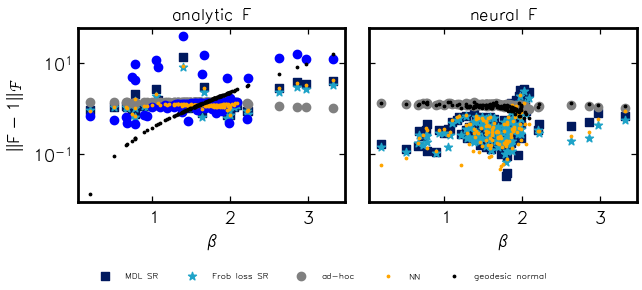

In [46]:
# make two-panel plot:

# COLOUR STUFF
fishercolour = "#1ea3c8"

myorange = '#a05a0a'

fishercolour = myorange
flatcolour = "#1ea3c8"


set_plot_fontsizes(base=16, ticks=16, legend=8, title=15)


figwidth = 3.41 * 2
figheight = figwidth * 0.65
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(figwidth, figheight), sharey=True)



ax = axs[0]

mdl_losses, _ = check_flattening(mdl_coords, X_test, Fs=true_fs / norm_factor)
mdl_losses = frb(mdl_losses)
mdl_score = mdl_losses.mean()

frob_losses, _ = check_flattening(frob_coords, X_test, Fs=true_fs / norm_factor)
frob_losses = frb(frob_losses)
frob_score = frob_losses.mean()

adhoc_losses, _ = check_flattening(ad_hoc_coords, X_test, Fs=true_fs / norm_factor)
adhoc_losses = frb(adhoc_losses)
adhoc_score = adhoc_losses.mean()


vanilla_coords = ["X1", "X2"]

vanilla_losses, _ = check_flattening(vanilla_coords, X_test, Fs=true_fs / norm_factor)
vanilla_losses = frb(vanilla_losses)


geo_score = frb(check_flattening(geo_coordinates, X_test, Fs=true_fs)[0]).mean()


# check neural network and numerical geodesic normal coord solution as well
nn_flats_, nn_score = check_neural_flattening(dy_sr_test, true_fs / norm_factor)
nn_losses = frb(nn_flats_)

geo2_flats, geo2_losses = check_numerical_fn_flattening(X_test, true_fs, myfunc=x_to_xprime)
geo2_score = geo2_losses.mean()

beta_geo_score = jax.vmap(get_beta)(X_test).mean()

geoscores = jax.vmap(get_beta)(X_test)

print("\nchecking against true fishers\n---")
print("neural network flattening score:", nn_score)
print("MDL SR flattening score:", mdl_score)
print("Frob SR flattening score:", frob_score)
print('ad-hoc flattening score:', adhoc_score)
# print('geo flattening score:', geo_score)
print('numerical geo flattening score:', geo2_score)
print('frob norm geo flattening score:', beta_geo_score)


# compare beta vs losses for each type of coord
skip = 20

ax.scatter(betas[::skip], mdl_losses[::skip], label='MDL SR', marker='s')
ax.scatter(betas[::skip], frob_losses[::skip], label='Frob loss SR', marker='*',c=flatcolour)


ax.scatter(betas[::skip], adhoc_losses[::skip], label='ad-hoc', c='grey')

ax.scatter(betas[::skip], vanilla_losses[::skip], label='vanilla', c='blue')

ax.scatter(betas[::skip], nn_losses[::skip], label='NN', s=3, c='orange')

ax.scatter(betas[::skip], geoscores[::skip], c='k', label='geodesic normal', s=3)

# ax.set_yscale('log')
ax.set_ylabel(r'$||\mathbf{F} - \mathbf{1}||_\mathcal{F}$')
ax.set_xlabel(r'$\beta$')
ax.set_title(r'analytic $F$')


## SECOND PLOT

ax = axs[1]





mdl_losses, _ = check_flattening(mdl_coords, X_test, Fs=Fs_test)
mdl_losses = frb(mdl_losses)
mdl_score = mdl_losses.mean()

frob_losses, _ = check_flattening(frob_coords, X_test, Fs=Fs_test)
frob_losses = frb(frob_losses)
frob_score = frob_losses.mean()

adhoc_losses, _ = check_flattening(ad_hoc_coords, X_test, Fs=Fs_test)
adhoc_losses = frb(adhoc_losses)
adhoc_score = adhoc_losses.mean()

geo_score = frb(check_flattening(geo_coordinates, X_test, Fs=Fs_test)[0]).mean()


# check neural network and numerical geodesic normal coord solution as well
nn_flats_, nn_score = check_neural_flattening(dy_sr_test, Fs_test)
nn_losses = frb(nn_flats_)

geo2_flats, geo2_losses = check_numerical_fn_flattening(X_test, Fs_test / 50, myfunc=x_to_xprime)
geo2_score = geo2_losses.mean()

print("\nchecking against true fishers\n---")
print("neural network flattening score:", nn_score)
print("MDL SR flattening score:", mdl_score)
print("Frob SR flattening score:", frob_score)
print('ad-hoc flattening score:', adhoc_score)
# print('geo flattening score:', geo_score)
print('numerical geo flattening score:', geo2_score)
print('frob norm geo flattening score:', beta_geo_score)



# compare beta vs losses for each type of coord

line1 = ax.scatter(betas[::skip], mdl_losses[::skip], label='MDL SR', marker='s')
line2 = ax.scatter(betas[::skip], frob_losses[::skip], label='Frob loss SR', marker='*', c=flatcolour)


line3 = ax.scatter(betas[::skip], adhoc_losses[::skip], label='ad-hoc', c='grey')

line4 = ax.scatter(betas[::skip], nn_losses[::skip], label='NN', s=3, c='orange')

line5 = ax.scatter(betas[::skip], geo2_losses[::skip], c='k', label='geodesic normal', s=3)

ax.set_yscale('log')
# ax.set_ylabel(r'$\mathcal{L} = ||g - I||_\mathcal{F}$')
ax.set_xlabel(r'$\beta$')


ax.set_title(r'neural $F$')



# plt.legend(framealpha=0.0, loc=(0.4,0.1), fontsize=12, ncols=1, bbox_to_anchor=(0.4,0.1))
# ax.legend(loc='upper left', bbox_to_anchor=(1.05, 1), borderaxespad=0., fontsize=12)



# Use fig.legend to center it under both plots
# loc='lower center' tells it to use the bottom of the legend as the anchor
fig.legend(handles=[line1, line2, line3, line4, line5], 
           loc='lower center', 
           ncol=5, 
           frameon=False,
           bbox_to_anchor=(0.5, 0.3)) # 0.5 is the middle of the whole figure

# Tighten the layout but leave a specific margin at the bottom for the legend
plt.tight_layout(rect=[0, 0.05, 1, 1]) 



# plt.tight_layout()
# # You might need to adjust the bottom margin if the legend is cut off
plt.subplots_adjust(bottom=0.5)

# plt.tight_layout()


plt.savefig('/Users/lucas/repositories/degeneracy_distillery/plots/mu_sigma_coordinate_compare.pdf',dpi=100, bbox_inches='tight')
plt.show()


In [121]:
def plot_flattening_comparison_analytic_only(
    betas,
    X_test,
    true_fs,
    mdl_coords,
    frob_coords,
    ad_hoc_coords,
    dy_sr_test,
    x_to_xprime,
    norm_factor,
    check_flattening,
    check_neural_flattening,
    check_numerical_fn_flattening,
    frb,
    get_beta=None,
    skip=20,
    figwidth=3.41,
    filename=None,
    style=None,
):
    """
    One-panel version of the flattening comparison plot using analytic Fisher results only.

    Parameters
    ----------
    betas : array-like
    X_test : array-like
    true_fs : array-like
    mdl_coords, frob_coords, ad_hoc_coords : symbolic coordinate definitions
    dy_sr_test : array-like
        Inputs for check_neural_flattening.
    x_to_xprime : callable
        Coordinate transform for numerical geodesic normal coordinates.
    norm_factor : float
    check_flattening, check_neural_flattening, check_numerical_fn_flattening, frb : callables
    get_beta : callable or None
        Optional, only used for printing beta_geo_score.
    skip : int
    figwidth : float
    filename : str or None
    style : dict or None
        Optional override for plotting styles.
    """
    import matplotlib.pyplot as plt
    import numpy as np

    default_style = {
        "mdl": {
            "label": "MDL SR",
            "color": "#2A9D8F",
            "marker": "s",
            "size": 34,
            "alpha": 0.9,
            "edgecolor": "white",
            "linewidth": 0.4,
        },
        "frob": {
            "label": "Frob loss SR",
            "color": "#0F766E",
            "marker": "D",
            "size": 32,
            "alpha": 0.9,
            "edgecolor": "white",
            "linewidth": 0.4,
        },
        "adhoc": {
            "label": "ad-hoc",
            "color": "#94A3B8",
            "marker": "o",
            "size": 28,
            "alpha": 0.85,
            "edgecolor": "white",
            "linewidth": 0.3,
        },
        "nn": {
            "label": "NN",
            "color": "#E76F51",
            "marker": "^",
            "size": 30,
            "alpha": 0.9,
            "edgecolor": "white",
            "linewidth": 0.35,
        },
        "geo": {
            "label": "geodesic normal",
            "color": "#264653",
            "marker": "P",
            "size": 30,
            "alpha": 0.9,
            "edgecolor": "white",
            "linewidth": 0.35,
        },
    }
    style = default_style if style is None else style

    def _scatter_method(ax, x, y, key):
        s = style[key]
        return ax.scatter(
            x, y,
            label=s["label"],
            c=s["color"],
            marker=s["marker"],
            s=s["size"],
            alpha=s["alpha"],
            edgecolors=s["edgecolor"],
            linewidths=s["linewidth"],
        )

    # Compute losses for analytic Fisher only
    mdl_losses, _ = check_flattening(mdl_coords, X_test, Fs=true_fs)
    mdl_losses = frb(mdl_losses)
    mdl_score = mdl_losses.mean()

    frob_losses, _ = check_flattening(frob_coords, X_test, Fs=true_fs)
    frob_losses = frb(frob_losses)
    frob_score = frob_losses.mean()

    adhoc_losses, _ = check_flattening(ad_hoc_coords, X_test, Fs=true_fs)
    adhoc_losses = frb(adhoc_losses)
    adhoc_score = adhoc_losses.mean()

    nn_flats_, nn_score = check_neural_flattening(dy_sr_test, true_fs)
    nn_losses = frb(nn_flats_)

    _, geo2_losses = check_numerical_fn_flattening(
        X_test, true_fs * norm_factor / 50, myfunc=x_to_xprime
    )
    geo2_score = geo2_losses.mean()

    print("\nchecking against analytic Fisher\n---")
    print("neural network flattening score:", nn_score)
    print("MDL SR flattening score:", mdl_score)
    print("Frob SR flattening score:", frob_score)
    print("ad-hoc flattening score:", adhoc_score)
    print("numerical geo flattening score:", geo2_score)
    if get_beta is not None:
        try:
            beta_geo_score = np.asarray([get_beta(x) for x in X_test]).mean()
            print("frob norm geo flattening score:", beta_geo_score)
        except Exception:
            pass

    xvals = betas[::skip]

    figheight = figwidth * 0.78
    fig, ax = plt.subplots(figsize=(figwidth, figheight))

    h1 = _scatter_method(ax, xvals, mdl_losses[::skip], "mdl")
    h2 = _scatter_method(ax, xvals, frob_losses[::skip], "frob")
    h3 = _scatter_method(ax, xvals, adhoc_losses[::skip], "adhoc")
    h4 = _scatter_method(ax, xvals, nn_losses[::skip], "nn")
    h5 = _scatter_method(ax, xvals, geo2_losses[::skip], "geo")

    ax.set_yscale("log")
    ax.set_ylabel(r"$||\mathbf{F} - \mathbf{1}||_\mathcal{F}$")
    ax.set_xlabel(r"$\beta$")
    ax.set_title(r"analytic $F$")
    ax.grid(alpha=0.2, which="both")

    ax.legend(
        handles=[h1, h2, h3, h4, h5],
        loc="upper center",
        bbox_to_anchor=(0.5, -0.3),
        ncol=3,
        frameon=False,
        fontsize=8,
        handlelength=1.2,
        columnspacing=1.0,
    )

    fig.subplots_adjust(left=0.17, right=0.98, top=0.90, bottom=0.28)

    if filename is not None:
        fig.savefig(filename, dpi=200, bbox_inches="tight")
        print(f"Saved plot to: {filename}")

    plt.show()
    return fig, ax

In [ ]:
def plot_flattening_comparison_analytic_only(
    betas,
    X_test,
    true_fs,
    mdl_coords,
    frob_coords,
    ad_hoc_coords,
    dy_sr_test,
    x_to_xprime,
    norm_factor,
    check_flattening,
    check_neural_flattening,
    check_numerical_fn_flattening,
    frb,
    get_beta=None,
    skip=20,
    figwidth=3.41,
    filename=None,
    style=None,
):
    """
    One-panel version of the flattening comparison plot using analytic Fisher results only.

    Parameters
    ----------
    betas : array-like
    X_test : array-like
    true_fs : array-like
    mdl_coords, frob_coords, ad_hoc_coords : symbolic coordinate definitions
    dy_sr_test : array-like
        Inputs for check_neural_flattening.
    x_to_xprime : callable
        Coordinate transform for numerical geodesic normal coordinates.
    norm_factor : float
    check_flattening, check_neural_flattening, check_numerical_fn_flattening, frb : callables
    get_beta : callable or None
        Optional, only used for printing beta_geo_score.
    skip : int
    figwidth : float
    filename : str or None
    style : dict or None
        Optional override for plotting styles.
    """
    import matplotlib.pyplot as plt
    import numpy as np

    default_style = {
        "mdl": {
            "label": "MDL SR",
            "color": "#2A9D8F",
            "marker": "s",
            "size": 34,
            "alpha": 0.9,
            "edgecolor": "white",
            "linewidth": 0.4,
        },
        "frob": {
            "label": "Frob loss SR",
            "color": "#0F766E",
            "marker": "D",
            "size": 32,
            "alpha": 0.9,
            "edgecolor": "white",
            "linewidth": 0.4,
        },
        "adhoc": {
            "label": "ad-hoc",
            "color": "#94A3B8",
            "marker": "o",
            "size": 28,
            "alpha": 0.85,
            "edgecolor": "white",
            "linewidth": 0.3,
        },
        "nn": {
            "label": "NN",
            "color": "#E76F51",
            "marker": "^",
            "size": 30,
            "alpha": 0.9,
            "edgecolor": "white",
            "linewidth": 0.35,
        },
        "geo": {
            "label": "geodesic normal",
            "color": "#264653",
            "marker": "P",
            "size": 30,
            "alpha": 0.9,
            "edgecolor": "white",
            "linewidth": 0.35,
        },
    }
    style = default_style if style is None else style

    def _scatter_method(ax, x, y, key):
        s = style[key]
        return ax.scatter(
            x, y,
            label=s["label"],
            c=s["color"],
            marker=s["marker"],
            s=s["size"],
            alpha=s["alpha"],
            edgecolors=s["edgecolor"],
            linewidths=s["linewidth"],
        )

    # Compute losses for analytic Fisher only
    mdl_losses, _ = check_flattening(mdl_coords, X_test, Fs=true_fs)
    mdl_losses = frb(mdl_losses)
    mdl_score = mdl_losses.mean()

    frob_losses, _ = check_flattening(frob_coords, X_test, Fs=true_fs)
    frob_losses = frb(frob_losses)
    frob_score = frob_losses.mean()

    adhoc_losses, _ = check_flattening(ad_hoc_coords, X_test, Fs=true_fs)
    adhoc_losses = frb(adhoc_losses)
    adhoc_score = adhoc_losses.mean()

    nn_flats_, nn_score = check_neural_flattening(dy_sr_test, true_fs)
    nn_losses = frb(nn_flats_)

    _, geo2_losses = check_numerical_fn_flattening(
        X_test, true_fs * norm_factor / 50, myfunc=x_to_xprime
    )
    geo2_score = geo2_losses.mean()

    print("\nchecking against analytic Fisher\n---")
    print("neural network flattening score:", nn_score)
    print("MDL SR flattening score:", mdl_score)
    print("Frob SR flattening score:", frob_score)
    print("ad-hoc flattening score:", adhoc_score)
    print("numerical geo flattening score:", geo2_score)
    if get_beta is not None:
        try:
            beta_geo_score = np.asarray([get_beta(x) for x in X_test]).mean()
            print("frob norm geo flattening score:", beta_geo_score)
        except Exception:
            pass

    xvals = betas[::skip]

    figheight = figwidth * 0.78
    fig, ax = plt.subplots(figsize=(figwidth, figheight))

    h1 = _scatter_method(ax, xvals, mdl_losses[::skip], "mdl")
    h2 = _scatter_method(ax, xvals, frob_losses[::skip], "frob")
    h3 = _scatter_method(ax, xvals, adhoc_losses[::skip], "adhoc")
    h4 = _scatter_method(ax, xvals, nn_losses[::skip], "nn")
    h5 = _scatter_method(ax, xvals, geo2_losses[::skip], "geo")

    ax.set_yscale("log")
    ax.set_ylabel(r"$||\mathbf{F} - \mathbf{1}||_\mathcal{F}$")
    ax.set_xlabel(r"$\beta$")
    ax.set_title(r"analytic $F$")
    ax.grid(alpha=0.2, which="both")

    ax.legend(
        handles=[h1, h2, h3, h4, h5],
        loc="upper center",
        bbox_to_anchor=(0.5, -0.3),
        ncol=3,
        frameon=False,
        fontsize=8,
        handlelength=1.2,
        columnspacing=1.0,
    )

    fig.subplots_adjust(left=0.17, right=0.98, top=0.90, bottom=0.28)

    if filename is not None:
        fig.savefig(filename, dpi=200, bbox_inches="tight")
        print(f"Saved plot to: {filename}")

    plt.show()
    return fig, ax


checking against analytic Fisher
---
neural network flattening score: 1.4043688
MDL SR flattening score: 1.33616
Frob SR flattening score: 1.3123462
ad-hoc flattening score: 1.0892093
numerical geo flattening score: 1.5643244


1 extra bytes in post.stringData array


frob norm geo flattening score: 1.5643246
Saved plot to: analytic_fisher_flattening.pdf


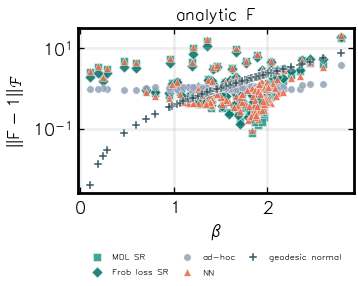

In [122]:
fig, ax = plot_flattening_comparison_analytic_only(
    betas=betas,
    X_test=X_test,
    true_fs=true_fs,
    mdl_coords=mdl_coords,
    frob_coords=frob_coords,
    ad_hoc_coords=ad_hoc_coords,
    dy_sr_test=dy_sr_test,
    x_to_xprime=x_to_xprime,
    norm_factor=norm_factor,
    check_flattening=check_flattening,
    check_neural_flattening=check_neural_flattening,
    check_numerical_fn_flattening=check_numerical_fn_flattening,
    frb=frb,
    get_beta=get_beta,
    skip=20,
    figwidth=3.41,
    filename="analytic_fisher_flattening.pdf",
)

In [47]:
def _weighted_quantile(
    values: np.ndarray, weights: np.ndarray, q: float
) -> float:
    """Smallest value with cumulative normalized weight >= q."""
    values = np.asarray(values, dtype=float)
    weights = np.asarray(weights, dtype=float)
    ok = np.isfinite(values) & np.isfinite(weights) & (weights > 0)
    if not np.any(ok):
        return float("nan")
    v = values[ok]
    w = weights[ok]
    w = w / np.sum(w)
    order = np.argsort(v)
    v = v[order]
    w = w[order]
    cw = np.cumsum(w)
    idx = int(np.searchsorted(cw, q, side="left"))
    idx = min(max(idx, 0), len(v) - 1)
    return float(v[idx])


def _histogram_uniform_beta_ipw(
    beta: np.ndarray, n_bins: int = 40, eps: float = 1e-14
) -> np.ndarray:
    """
    Importance weights approximating a uniform target on [min(beta), max(beta)].

    Uses a histogram estimate :math:`\\hat p` of the sampling density on finite
    ``beta``; each finite sample gets weight proportional to
    :math:`1 / (n_k / \\Delta_k)` (i.e. :math:`q/\\hat p` with :math:`q=1/R`),
    then weights are scaled to mean 1 over finite entries.
    """
    beta = np.asarray(beta, dtype=float)
    n = beta.size
    w = np.ones(n, dtype=float)
    fin = np.isfinite(beta)
    n_f = int(np.sum(fin))
    if n_f < 2:
        return w
    b = beta[fin]
    lo, hi = float(np.min(b)), float(np.max(b))
    R = hi - lo
    if R <= eps * 100:
        return w
    n_bins = max(int(n_bins), 2)
    edges_d = np.linspace(lo, hi, n_bins + 1)
    widths = np.diff(edges_d)
    idx_d = np.digitize(beta, edges_d) - 1
    idx_d = np.clip(idx_d, 0, n_bins - 1)
    counts = np.bincount(idx_d[fin], minlength=n_bins).astype(float)
    nk_at = counts[idx_d]
    Delta_at = widths[idx_d]
    w_raw = np.ones(n, dtype=float)
    dens = np.maximum(nk_at[fin], 0.5) / (n_f * Delta_at[fin])
    w_raw[fin] = (1.0 / R) / np.maximum(dens, eps / R)
    m = float(np.mean(w_raw[fin]))
    if m > 0:
        w_raw[fin] /= m
    return w_raw



In [52]:
def plot_flattening_comparison_analytic_binned(
    betas,
    X_test,
    true_fs,
    mdl_coords,
    frob_coords,
    ad_hoc_coords,
    dy_sr_test,
    x_to_xprime,
    norm_factor,
    check_flattening,
    check_neural_flattening,
    check_numerical_fn_flattening,
    frb,
    get_beta=None,
    beta_bins=12,
    plot_vanilla=True,
    statistic="median",
    spread="iqr",
    min_count=5,
    beta_bin_weight="cumulative",
    aggregate_in_log_space=True,
    beta_sampling_correction=None,
    beta_density_bins=None,
    xlabel=r"$\beta$",
    figwidth=3.41,
    filename=None,
    style=None,
    show=True,
):
    """
    Binned analytic-Fisher-only flattening comparison.

    For each method, compute losses at all beta values, bin by beta,
    and plot one summary point per beta bin.

    Parameters
    ----------
    beta_bins : int or array-like
        Number of equal-width bins, or explicit bin edges.
    statistic : {"median", "mean"}
        Per-bin summary statistic.
    spread : {"iqr", "std", "sem", None}
        Spread shown as a shaded band.
    min_count : int
        Minimum number of samples required in a bin to plot it.
    beta_bin_weight : {None, "cumulative", "mass", "downweight_sparse",
        "inverse_mass"}, optional
        If not None, each bin's weight :math:`w` (from sample counts and
        ``X_test.shape[0]``) is folded **into** the loss aggregation: with
        ``aggregate_in_log_space=True``, use :math:`\\log y + \\log w` before
        median/mean/percentiles/std; with ``aggregate_in_log_space=False``,
        scale losses as :math:`y \\cdot w` before those statistics. This matches
        multiplying the aggregated summary by :math:`w` when :math:`w` is
        constant within the bin, but is the correct stage for log-domain
        summaries.

        To **downweight bins with fewer samples** (trust dense :math:`\\beta`
        regions more), use ``"mass"`` or the equivalent alias
        ``"downweight_sparse"``: :math:`w_k \\propto n_k`, so sparse bins get
        smaller multipliers than data-rich bins.

        **Not** a :math:`\\beta`-integral: no mode implements
        :math:`\\int L(\\beta)\\,d\\beta` (that would use bin width
        :math:`\\Delta\\beta` times bin means, with **no** factor of
        :math:`n_k`; use ``None`` with equal-width bins if bin means are the
        quantity of interest).

        - ``"cumulative"``: :math:`w_k = n_{\\leq k}/n_{\\mathrm{tot}}` (finite
          ``betas`` through bin :math:`k`'s right edge). **Downweights** early
          :math:`\\beta` when few samples lie there; does **not** upweight
          sparse bins.
        - ``"mass"`` / ``"downweight_sparse"``: :math:`w_k = n_k/n_{\\mathrm{tot}}`
          (samples in bin). Linear **downweighting** of sparse bins; same
          weighting that rebuilds a global **sample** mean from per-bin means
          :math:`\\sum_k (n_k/n)\\bar y_k`.
        - ``"inverse_mass"``: :math:`w_k = (n_{\\mathrm{tot}}/B)/n_k` with
          :math:`B` the nominal number of :math:`\\beta` intervals (``beta_bins``
          if scalar, else ``len(bins)-1``). **Upweights** bins with fewer than
          uniformly-spread samples (:math:`w_k=1` when :math:`n_k = n_{\\mathrm{tot}}/B`).

        Use ``None`` for no scaling (raw binned median/mean and spread).

    aggregate_in_log_space : bool
        If True (default), per-bin ``statistic`` and ``spread`` are computed on
        :math:`\\log y` (with :math:`y` floored to ``1e-14``), then mapped
        back with :math:`\\exp` for plotting. ``mean`` becomes the geometric
        mean; ``median`` matches the usual median on :math:`y` for positive
        data. ``std`` / ``sem`` bands use :math:`\\exp(c \\pm s)` with
        :math:`c` the log-space center (median or mean of :math:`\\log y`,
        matching ``statistic``) and :math:`s` the log-space standard error.

    beta_sampling_correction : {None, "uniform_histogram"}, optional
        If ``"uniform_histogram"``, estimate the empirical density of
        ``betas`` with a histogram on ``[\\min\\beta, \\max\\beta]`` and apply
        per-sample importance weights :math:`\\propto q(\\beta)/\\hat p(\\beta)`
        with :math:`q` uniform (approximates debiasing uneven :math:`\\beta`
        sampling when aggregating within each plot bin). Uses
        ``beta_density_bins`` intervals for :math:`\\hat p`.
    beta_density_bins : int, optional
        Histogram bin count for :math:`\\hat p(\\beta)` when using
        ``beta_sampling_correction="uniform_histogram"``. Default scales
        with ``beta_bins``.
    """
    import matplotlib.pyplot as plt

    default_style = {
        "vanilla": {
            "label": r"$\theta$",
            "color": "#7C2A2A",
            "marker": "o",
            "size": 30,
            "alpha": 0.67,
            "edgecolor": "white",
            "linewidth": 0.4,
            "linestyle": "-",
        },
                     
        "mdl": {
            "label": "MDL SR",
            "color": "#2A9D8F",
            "marker": "s",
            "size": 30,
            "alpha": 0.95,
            "edgecolor": "white",
            "linewidth": 0.4,
            "linestyle": "-",
        },
        "frob": {
            "label": "Frob loss SR",
            "color": "#0F766E",
            "marker": "D",
            "size": 28,
            "alpha": 0.95,
            "edgecolor": "white",
            "linewidth": 0.4,
            "linestyle": "-",
        },
        "adhoc": {
            "label": "ad-hoc",
            "color": "#94A3B8",
            "marker": "o",
            "size": 26,
            "alpha": 0.9,
            "edgecolor": "white",
            "linewidth": 0.3,
            "linestyle": "-",
        },
        "nn": {
            "label": "NN",
            "color": "#E76F51",
            "marker": "^",
            "size": 28,
            "alpha": 0.95,
            "edgecolor": "white",
            "linewidth": 0.35,
            "linestyle": "-",
        },
        "geo": {
            "label": "geodesic normal",
            "color": "#264653",
            "marker": "P",
            "size": 28,
            "alpha": 0.95,
            "edgecolor": "white",
            "linewidth": 0.35,
            "linestyle": "-",
        },
    }
    style = default_style if style is None else style
    betas = np.asarray(betas)
    n_denominator = int(X_test.shape[0])

    if beta_bin_weight is not None and beta_bin_weight not in (
        "cumulative",
        "mass",
        "downweight_sparse",
        "inverse_mass",
    ):
        raise ValueError(
            'beta_bin_weight must be None, "cumulative", "mass", '
            '"downweight_sparse", or "inverse_mass"'
        )

    if beta_sampling_correction not in (None, "uniform_histogram"):
        raise ValueError(
            'beta_sampling_correction must be None or "uniform_histogram"'
        )

    if np.isscalar(beta_bins):
        _n_plot_bins = int(beta_bins)
    else:
        _n_plot_bins = max(len(np.asarray(beta_bins)) - 1, 2)

    if beta_density_bins is None:
        beta_density_bins = int(max(12, min(120, _n_plot_bins * 3)))
    else:
        beta_density_bins = int(beta_density_bins)

    def _make_bins(x, bins):
        x = np.asarray(x)
        if np.isscalar(bins):
            return np.linspace(np.nanmin(x), np.nanmax(x), int(bins) + 1)
        return np.asarray(bins)

    def _bin_xy(
        x,
        y,
        bins,
        statistic="median",
        spread="iqr",
        min_count=5,
        *,
        beta_for_cumulative=None,
        n_denominator_inner=None,
        beta_bin_weight_inner=None,
        n_beta_intervals=None,
        aggregate_in_log_space_inner=True,
        beta_sampling_correction_inner=None,
        beta_density_bins_inner=40,
    ):
        x = np.asarray(x)
        y = np.asarray(y)
        y_floor = 1e-14
        beta_ref = (
            np.asarray(beta_for_cumulative)
            if beta_for_cumulative is not None
            else x
        )
        n_tot = (
            int(n_denominator_inner)
            if n_denominator_inner is not None
            else beta_ref.shape[0]
        )

        if beta_sampling_correction_inner == "uniform_histogram":
            ipw_full = _histogram_uniform_beta_ipw(
                x, n_bins=int(beta_density_bins_inner)
            )
        else:
            ipw_full = np.ones(x.shape[0], dtype=float)

        mask = np.isfinite(x) & np.isfinite(y)
        ipw_masked = ipw_full[mask]
        x = x[mask]
        y = y[mask]

        edges = _make_bins(x, bins)
        centers = 0.5 * (edges[:-1] + edges[1:])
        idx = np.digitize(x, edges) - 1

        x_out, y_out, y_lo, y_hi, counts = [], [], [], [], []

        for i in range(len(edges) - 1):
            m = idx == i
            if m.sum() < min_count:
                continue

            yy = y[m]
            n_bin = int(m.sum())

            if beta_bin_weight_inner is None or n_tot <= 0:
                w_bin = 1.0
            elif beta_bin_weight_inner == "cumulative":
                n_w = int(
                    np.sum(
                        np.isfinite(beta_ref)
                        & (beta_ref <= edges[i + 1])
                    )
                )
                w_bin = n_w / float(n_tot)
            elif beta_bin_weight_inner in ("mass", "downweight_sparse"):
                w_bin = n_bin / float(n_tot)
            elif beta_bin_weight_inner == "inverse_mass":
                B = int(n_beta_intervals) if n_beta_intervals is not None else 1
                B = max(B, 1)
                if n_bin > 0:
                    w_bin = (n_tot / float(B)) / float(n_bin)
                else:
                    w_bin = 1.0
            else:
                raise ValueError(
                    'beta_bin_weight_inner must be "cumulative", '
                    '"mass", "downweight_sparse", "inverse_mass", or None'
                )

            w_bin = max(float(w_bin), y_floor)

            sw = ipw_masked[m].astype(float)
            if not np.all(np.isfinite(sw)) or np.sum(sw) <= 0:
                sw = np.ones_like(yy, dtype=float)
            zz = yy * w_bin

            if aggregate_in_log_space_inner:
                lzz = np.log(np.maximum(zz, y_floor))
                if statistic == "median":
                    center_log = _weighted_quantile(lzz, sw, 0.5)
                elif statistic == "mean":
                    center_log = float(np.average(lzz, weights=sw))
                else:
                    raise ValueError("statistic must be 'median' or 'mean'")
                yc = np.exp(center_log)

                if spread is None:
                    lo = hi = yc
                elif spread == "iqr":
                    lo = np.exp(_weighted_quantile(lzz, sw, 0.25))
                    hi = np.exp(_weighted_quantile(lzz, sw, 0.75))
                elif spread == "std":
                    resid = lzz - center_log
                    var = float(np.average(resid**2, weights=sw))
                    s = float(np.sqrt(max(var, 0.0)))
                    lo = np.exp(center_log - s)
                    hi = np.exp(center_log + s)
                elif spread == "sem":
                    resid = lzz - center_log
                    var = float(np.average(resid**2, weights=sw))
                    sum_sw = float(np.sum(sw))
                    sw2 = float(np.sum(sw**2))
                    n_eff = (sum_sw**2) / sw2 if sw2 > 0 else float(n_bin)
                    s = float(np.sqrt(max(var, 0.0) / max(n_eff, 1e-9)))
                    lo = np.exp(center_log - s)
                    hi = np.exp(center_log + s)
                else:
                    raise ValueError(
                        "spread must be one of: 'iqr', 'std', 'sem', None"
                    )
            else:
                if statistic == "median":
                    yc = _weighted_quantile(zz, sw, 0.5)
                elif statistic == "mean":
                    yc = float(np.average(zz, weights=sw))
                else:
                    raise ValueError("statistic must be 'median' or 'mean'")

                if spread is None:
                    lo = hi = yc
                elif spread == "iqr":
                    lo = _weighted_quantile(zz, sw, 0.25)
                    hi = _weighted_quantile(zz, sw, 0.75)
                elif spread == "std":
                    resid = zz - yc
                    var = float(np.average(resid**2, weights=sw))
                    s = float(np.sqrt(max(var, 0.0)))
                    lo = yc - s
                    hi = yc + s
                elif spread == "sem":
                    resid = zz - yc
                    var = float(np.average(resid**2, weights=sw))
                    sum_sw = float(np.sum(sw))
                    sw2 = float(np.sum(sw**2))
                    n_eff = (sum_sw**2) / sw2 if sw2 > 0 else float(n_bin)
                    s = float(np.sqrt(max(var, 0.0) / max(n_eff, 1e-9)))
                    lo = yc - s
                    hi = yc + s
                else:
                    raise ValueError(
                        "spread must be one of: 'iqr', 'std', 'sem', None"
                    )

            lo = max(lo, 1e-14)
            hi = max(hi, 1e-14)
            yc = max(yc, 1e-14)

            x_out.append(centers[i])
            y_out.append(yc)
            y_lo.append(lo)
            y_hi.append(hi)
            counts.append(n_bin)

        return (
            np.asarray(x_out),
            np.asarray(y_out),
            np.asarray(y_lo),
            np.asarray(y_hi),
            np.asarray(counts),
        )

    n_beta_intervals_for_weight = _n_plot_bins

    def _plot_binned(ax, x, y, key, show_band=True):
        xb, yb, ylo, yhi, counts = _bin_xy(
            x,
            y,
            bins=beta_bins,
            statistic=statistic,
            spread=spread,
            min_count=min_count,
            beta_for_cumulative=betas,
            n_denominator_inner=n_denominator,
            beta_bin_weight_inner=beta_bin_weight,
            n_beta_intervals=n_beta_intervals_for_weight,
            aggregate_in_log_space_inner=aggregate_in_log_space,
            beta_sampling_correction_inner=beta_sampling_correction,
            beta_density_bins_inner=beta_density_bins,
        )

        if len(xb) == 0:
            return None

        s = style[key]
        handle = ax.scatter(
            xb,
            yb,
            label=s["label"],
            c=s["color"],
            marker=s["marker"],
            s=s["size"],
            alpha=s["alpha"],
            edgecolors=s["edgecolor"],
            linewidths=s["linewidth"],
            zorder=3,
        )

        ax.plot(
            xb,
            yb,
            color=s["color"],
            linestyle=s.get("linestyle", "-"),
            linewidth=1.2,
            alpha=0.9,
            zorder=2,
        )

        if spread is not None and show_band:
            ax.fill_between(
                xb,
                ylo,
                yhi,
                color=s["color"],
                alpha=0.14,
                linewidth=0,
                zorder=1,
            )

        return handle

    vanilla_coords = ['X1', 'X2']
    vanilla_losses, _ = check_flattening(vanilla_coords, X_test, Fs=true_fs)
    vanilla_losses = np.asarray(frb(vanilla_losses))
    vanilla_score = vanilla_losses.mean()

    mdl_losses, _ = check_flattening(mdl_coords, X_test, Fs=true_fs)
    mdl_losses = np.asarray(frb(mdl_losses))
    mdl_score = mdl_losses.mean()

    frob_losses, _ = check_flattening(frob_coords, X_test, Fs=true_fs)
    frob_losses = np.asarray(frb(frob_losses))
    frob_score = frob_losses.mean()

    adhoc_losses, _ = check_flattening(ad_hoc_coords, X_test, Fs=true_fs)
    adhoc_losses = np.asarray(frb(adhoc_losses))
    adhoc_score = adhoc_losses.mean()

    nn_flats_, nn_score = check_neural_flattening(dy_sr_test, true_fs)
    nn_losses = np.asarray(frb(nn_flats_))

    _, geo2_losses = check_numerical_fn_flattening(
        X_test, true_fs * norm_factor / 50, myfunc=x_to_xprime
    )
    geo2_losses = np.asarray(geo2_losses)
    geo2_score = geo2_losses.mean()

    print("\nchecking against analytic Fisher\n---")
    print("vanilla coords (theta) flattening score:", vanilla_score)
    print("neural network flattening score:", nn_score)
    print("MDL SR flattening score:", mdl_score)
    print("Frob SR flattening score:", frob_score)
    print("ad-hoc flattening score:", adhoc_score)
    print("numerical geo flattening score:", geo2_score)
    if get_beta is not None:
        try:
            beta_geo_score = np.asarray([get_beta(x) for x in X_test]).mean()
            print("frob norm geo flattening score:", beta_geo_score)
        except Exception:
            pass

    figheight = figwidth * 0.82
    fig, ax = plt.subplots(figsize=(figwidth, figheight))

    if plot_vanilla:
      h0 = _plot_binned(ax, betas, vanilla_losses, "vanilla")
    h1 = _plot_binned(ax, betas, mdl_losses, "mdl")
    h2 = _plot_binned(ax, betas, frob_losses, "frob")
    h3 = _plot_binned(ax, betas, adhoc_losses, "adhoc")
    h4 = _plot_binned(ax, betas, nn_losses, "nn")
    h5 = _plot_binned(ax, betas, geo2_losses, "geo", show_band=False)

    ax.set_yscale("log")
    # ax.set_xscale("log")
    ax.set_ylabel(r"$||\mathbf{F} - \mathbf{1}||_\mathcal{F}$")
    ax.set_xlabel(xlabel)
    ax.set_ylim(1e-3, None)

    if plot_vanilla:
      handles = [h for h in [h0, h1, h2, h3, h4, h5] if h is not None]
    else:
      handles = [h for h in [h1, h2, h3, h4, h5] if h is not None]
    ax.legend(
        handles=handles,
        loc="upper center",
        bbox_to_anchor=(0.5, -0.3),
        ncol=min(3, len(handles)),
        frameon=False,
        fontsize=8,
        handlelength=1.2,
        columnspacing=1.0,
    )

    fig.subplots_adjust(left=0.17, right=0.98, top=0.90, bottom=0.28)

    if filename is not None:
        fig.savefig(filename, dpi=200, bbox_inches="tight")
        print(f"Saved plot to: {filename}")

    if show:
        plt.show()
    else:
        plt.close(fig)

    return fig, ax


checking against analytic Fisher
---
vanilla coords (theta) flattening score: 5.8887334
neural network flattening score: 1.7297384
MDL SR flattening score: 1.9126769
Frob SR flattening score: 1.6005903
ad-hoc flattening score: 1.144962
numerical geo flattening score: 1.2507347


1 extra bytes in post.stringData array


Saved plot to: analytic_fisher_flattening.pdf


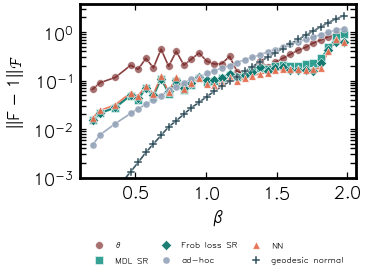

In [56]:
mask = betas < 2.0


fig, ax = plot_flattening_comparison_analytic_binned(
    # betas=X_test[:, 1],
    betas=(betas)[mask],
    X_test=X_test[mask],
    true_fs=true_fs[mask],
    mdl_coords=mdl_coords,
    frob_coords=frob_coords,
    ad_hoc_coords=ad_hoc_coords,
    dy_sr_test=dy_sr_test[mask],
    x_to_xprime=x_to_xprime,
    norm_factor=norm_factor,
    check_flattening=check_flattening,
    check_neural_flattening=check_neural_flattening,
    check_numerical_fn_flattening=check_numerical_fn_flattening,
    frb=frb,
    beta_bins=35,
    statistic="median",
    # beta_bin_weight="mass",
    aggregate_in_log_space=False,
        # beta_sampling_correction="uniform_histogram",
        # beta_density_bins = 100,
    # xlabel=r"$\theta_0$",
    spread=None,
    filename="analytic_fisher_flattening.pdf",
)

In [43]:
mdl_coords

['(7.271622 + ((((exp((0.952197 * X2)) + (((-1.258422) * X1) * (2.666616 * X1))) * (0.016555 * X1)) + (2.784939 * X1)) * (exp((0.135525 * X2)) + ((-0.366447) * X2))))',
 '((-0.726524) + ((-11.446799) * ((-0.251491) * ((((((1.860714 * X1) * (0.073813 * X1)) + (0.425107 * X2)) + ((-0.015005) * X1)) ^ exp(((-0.272544) * X2))) * exp((0.124175 * X2))))))']

In [ ]:
mask = betas < 2.0

_xgrd = np.linspace(MIN

fig, ax = plot_flattening_comparison_analytic_binned(
    # betas=X_test[:, 1],
    betas=(betas)[mask],
    X_test=X_test[mask],
    true_fs=true_fs[mask],
    mdl_coords=mdl_coords,
    frob_coords=frob_coords,
    ad_hoc_coords=ad_hoc_coords,
    dy_sr_test=dy_sr_test[mask],
    x_to_xprime=x_to_xprime,
    norm_factor=norm_factor,
    check_flattening=check_flattening,
    check_neural_flattening=check_neural_flattening,
    check_numerical_fn_flattening=check_numerical_fn_flattening,
    frb=frb,
    beta_bins=35,
    statistic="median",
    # beta_bin_weight="mass",
    aggregate_in_log_space=False,
        # beta_sampling_correction="uniform_histogram",
        # beta_density_bins = 100,
    # xlabel=r"$\theta_0$",
    spread=None,
    filename="analytic_fisher_flattening_2.pdf",
)